In [28]:
from astropy.io import fits
import numpy as np
import os

cwd = os.getcwd()
path = rf"{cwd}\Gaia_dr2_in100pc1.fits"
file  = fits.open(path)[1]
data = file.data




Coordinate handling for Hyades

In [29]:
RA_hya = (4 + 30/60 + 27.4/3600)*15
# Convert RA from hours to degrees

DEC_hya = 16 + 46/60 + 43/3600
# Convert DEC with minutes and seconds to degrees with decimals instead

# SELECTING STARS

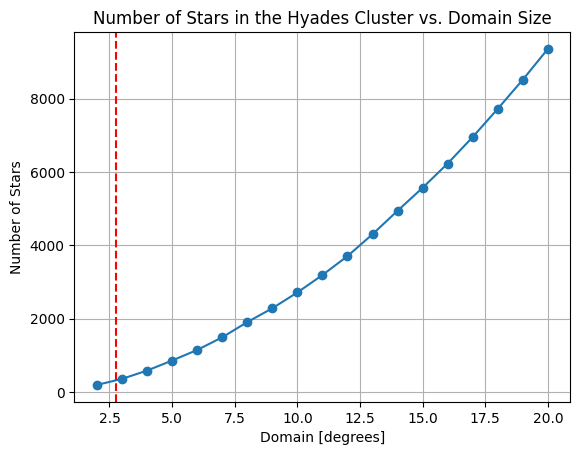

In [30]:
Delta = 5.5/2 # https://www.constellation-guide.com/hyades/

domain = np.arange(2,21,1)
N_stars = []
for D in domain:
    ra, dec = data['ra'], data['dec']
    mask_ra = (RA_hya-D <= ra) & (ra <= RA_hya+D ) # ra ∈ (RA_hya-D, RA_hya+D)
    mask_dec = (DEC_hya-D <= dec) & (dec <= DEC_hya+D ) # dec ∈ (DEC_hya-D, DEC_hya+D)
    filtered_data = data[mask_ra & mask_dec] 
    n_stars = len(filtered_data)
    N_stars.append(n_stars)

%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(domain, N_stars, marker='o')
plt.axvline(x=Delta,  color='r', linestyle='--', label=f'Literary Value = {Delta} degrees')
plt.xlabel('Domain [degrees]')
plt.ylabel('Number of Stars')
plt.title('Number of Stars in the Hyades Cluster vs. Domain Size')
plt.grid()
plt.show()

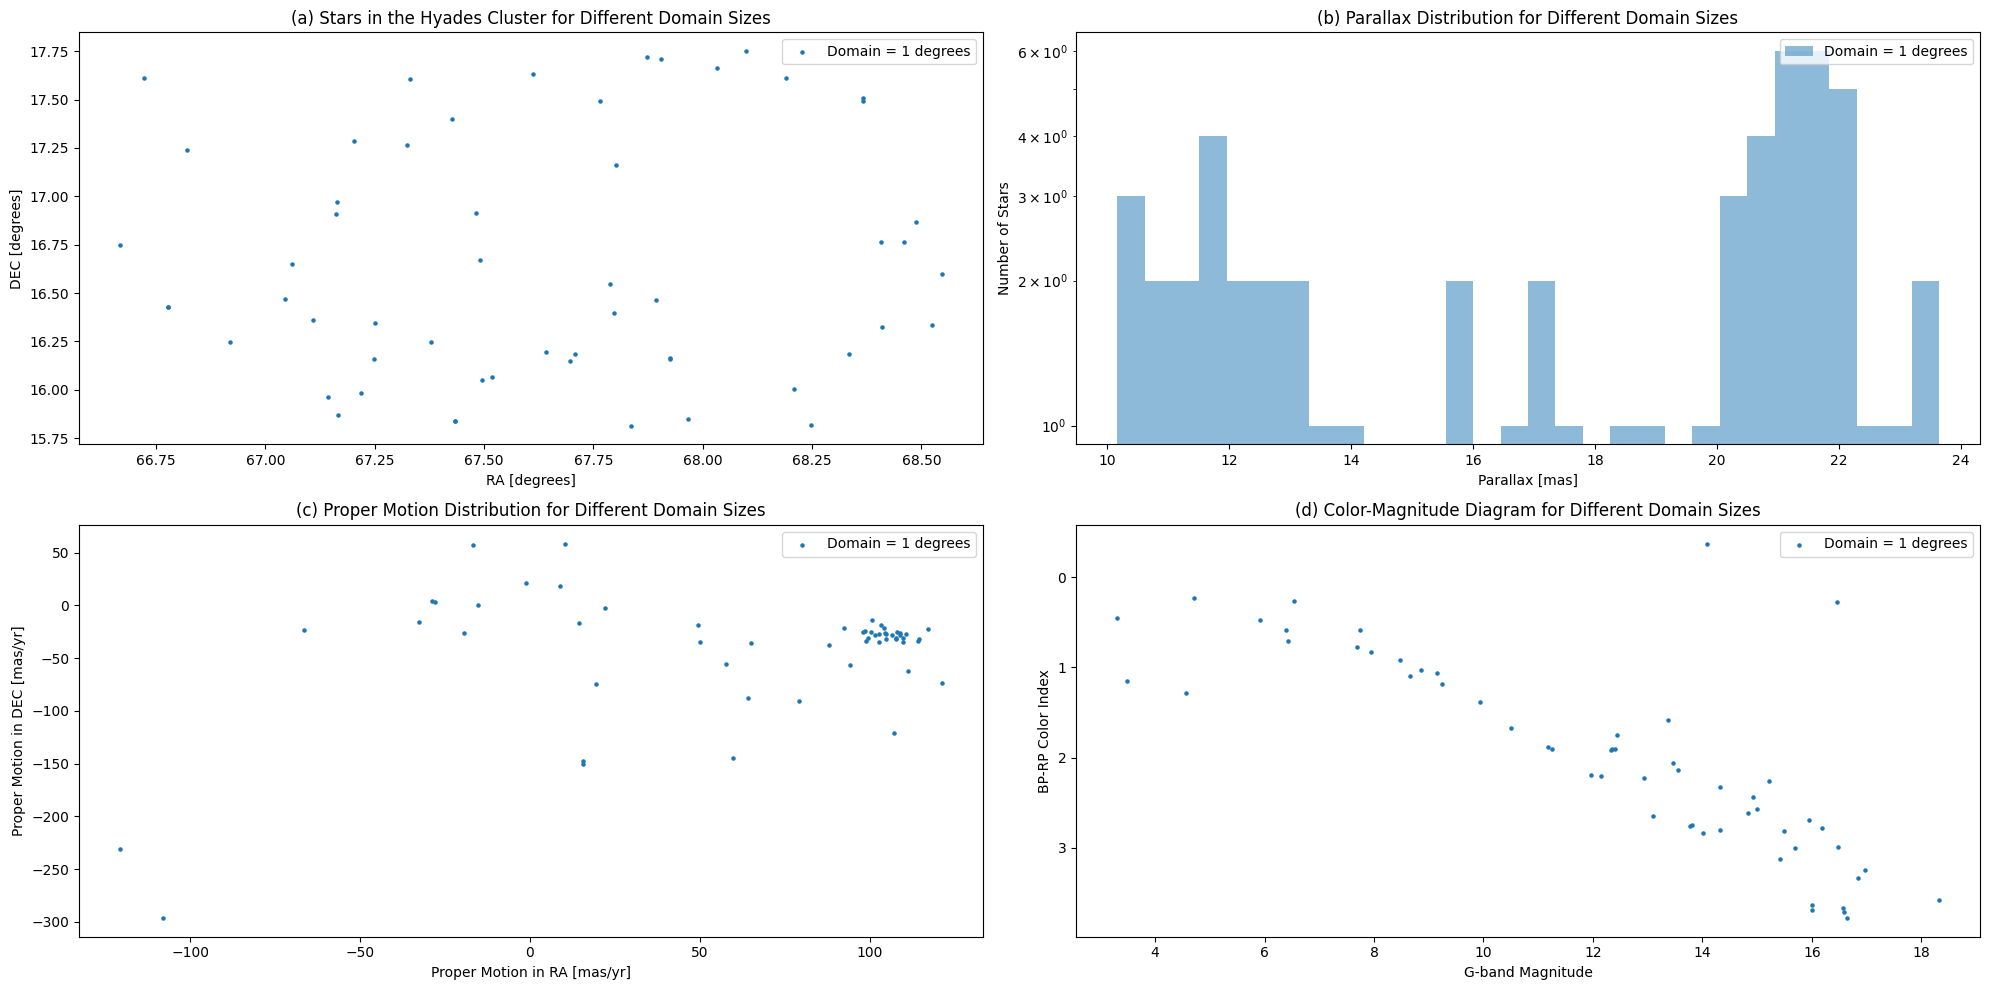

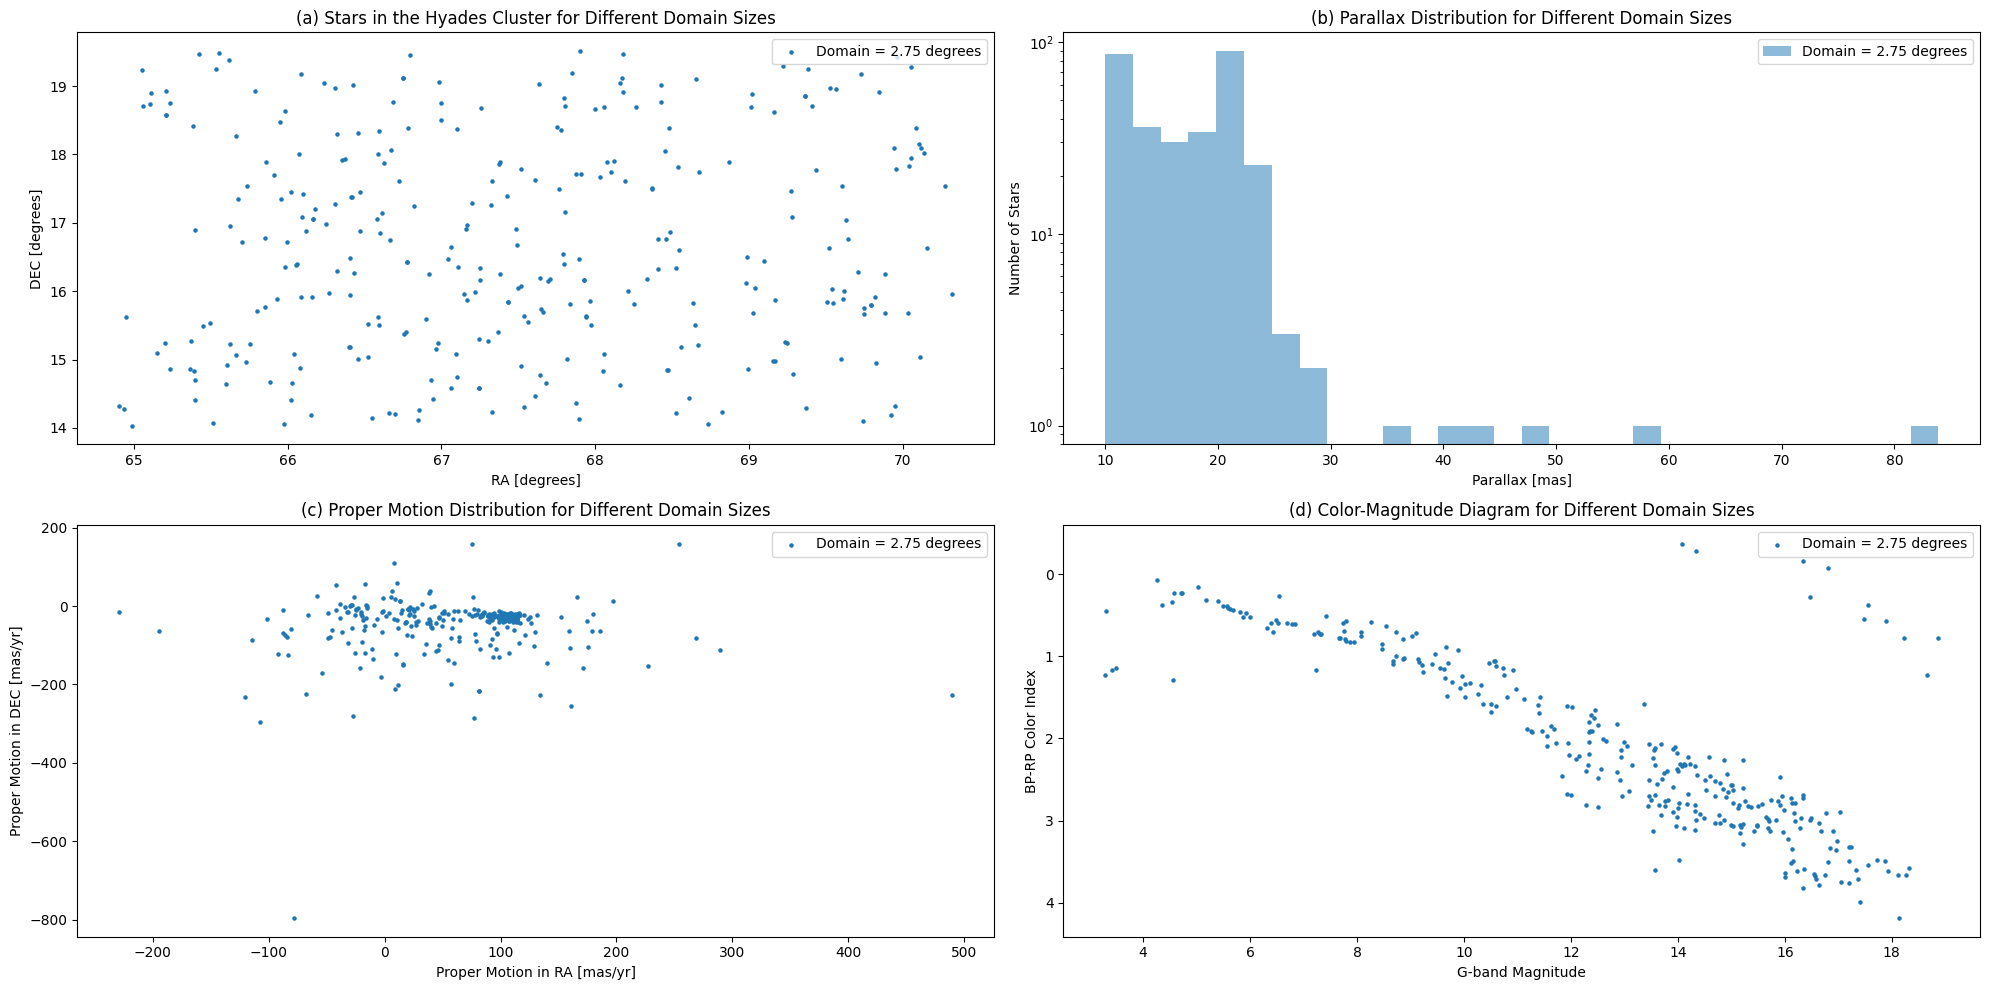

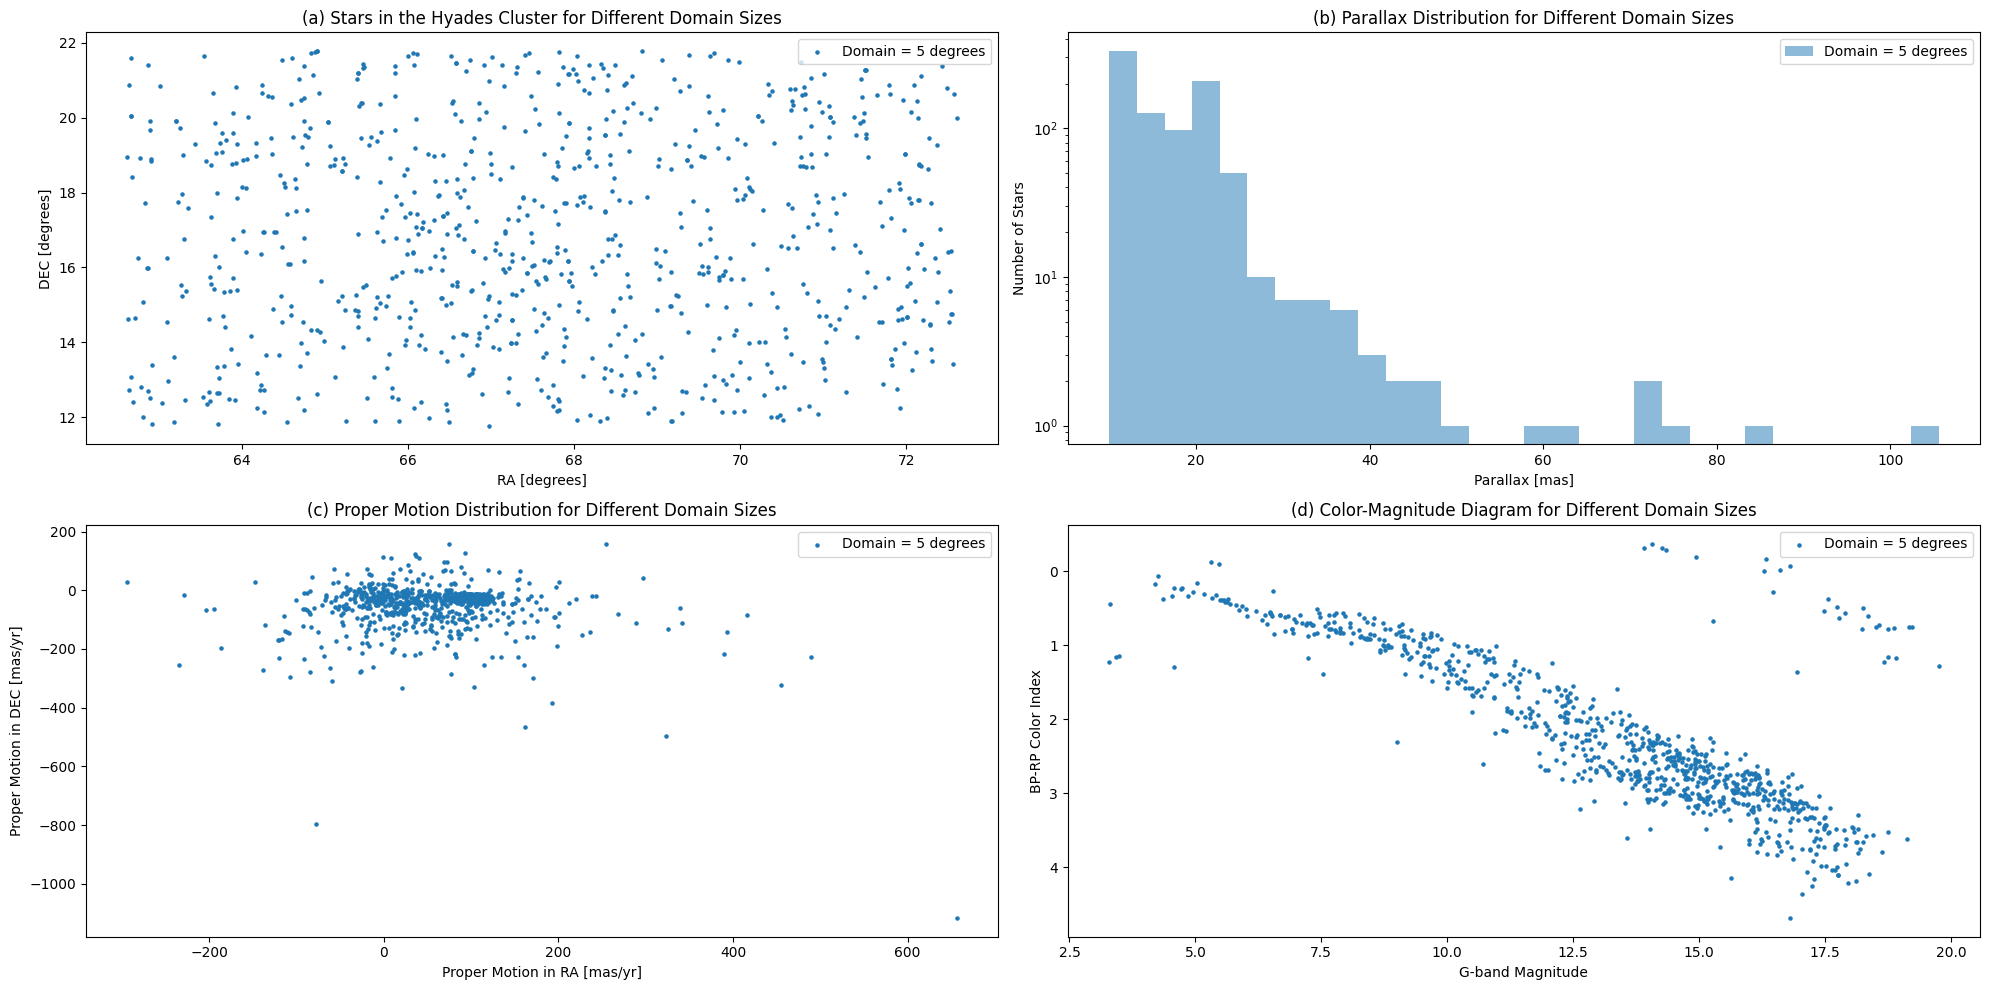

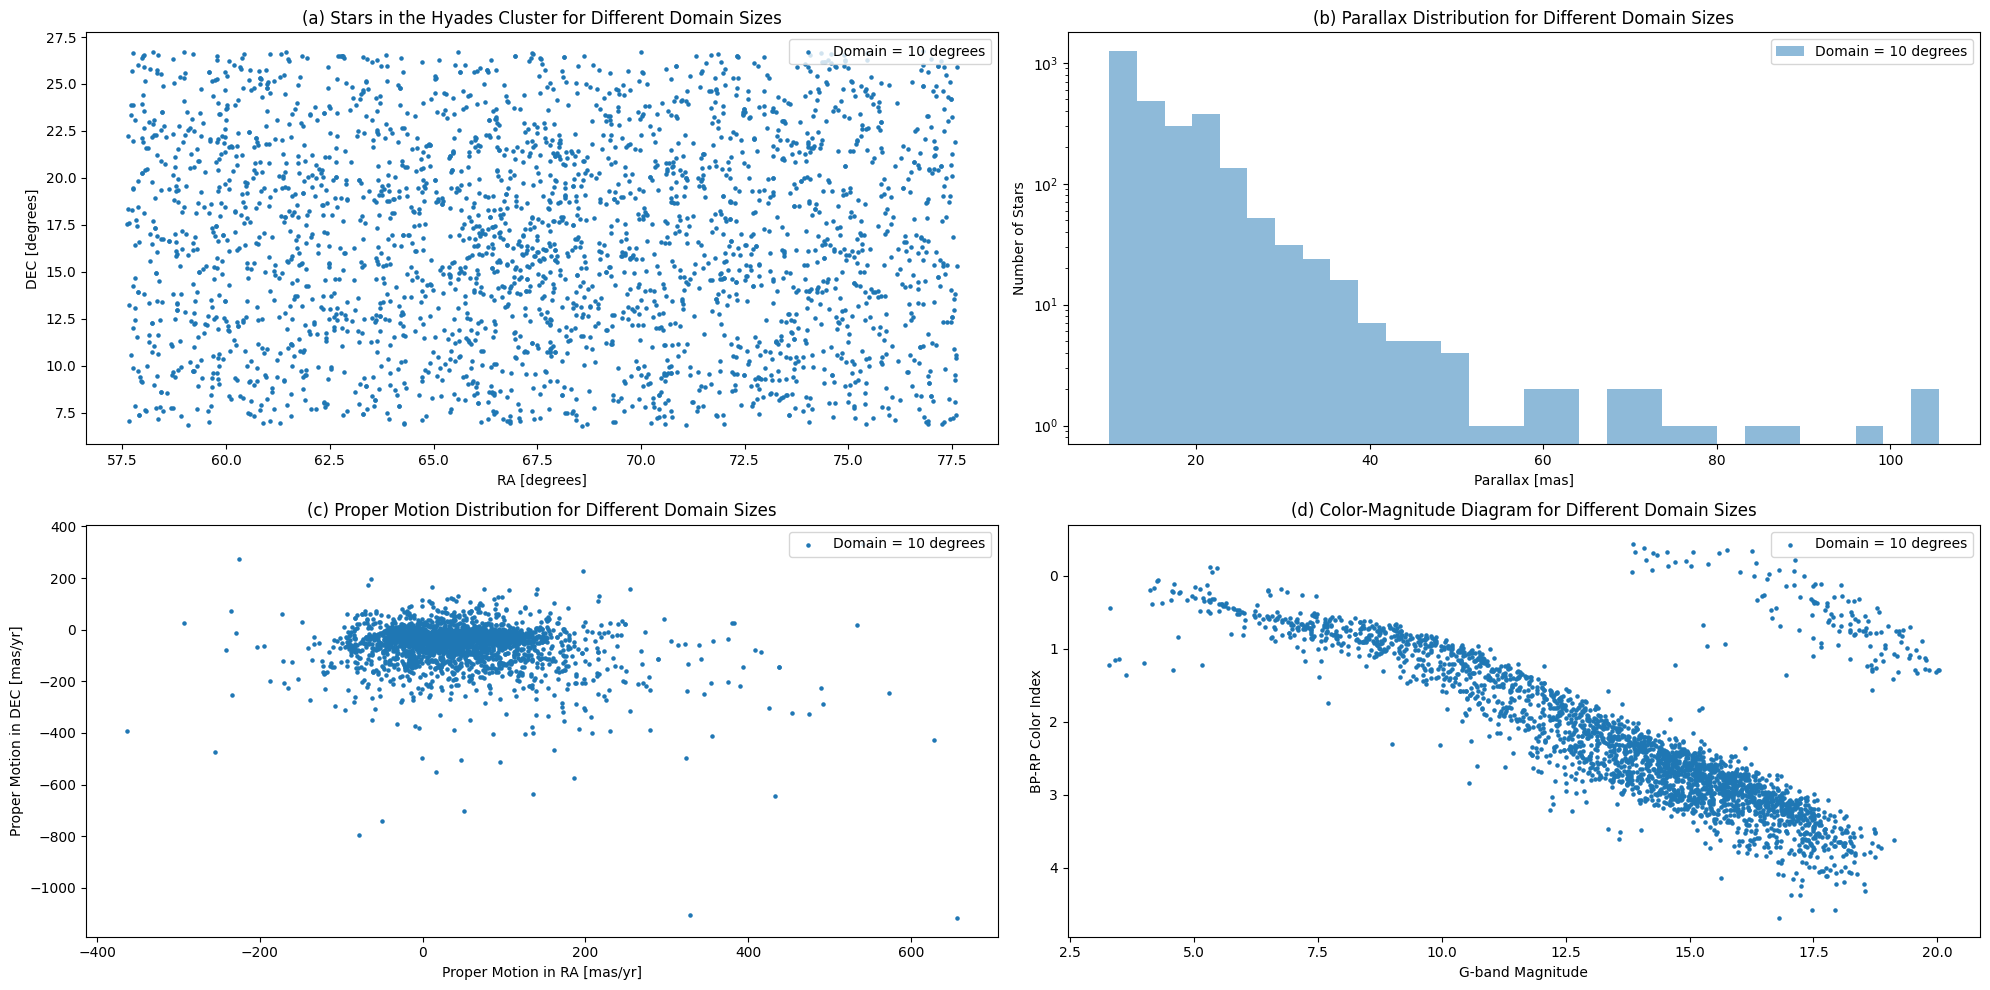

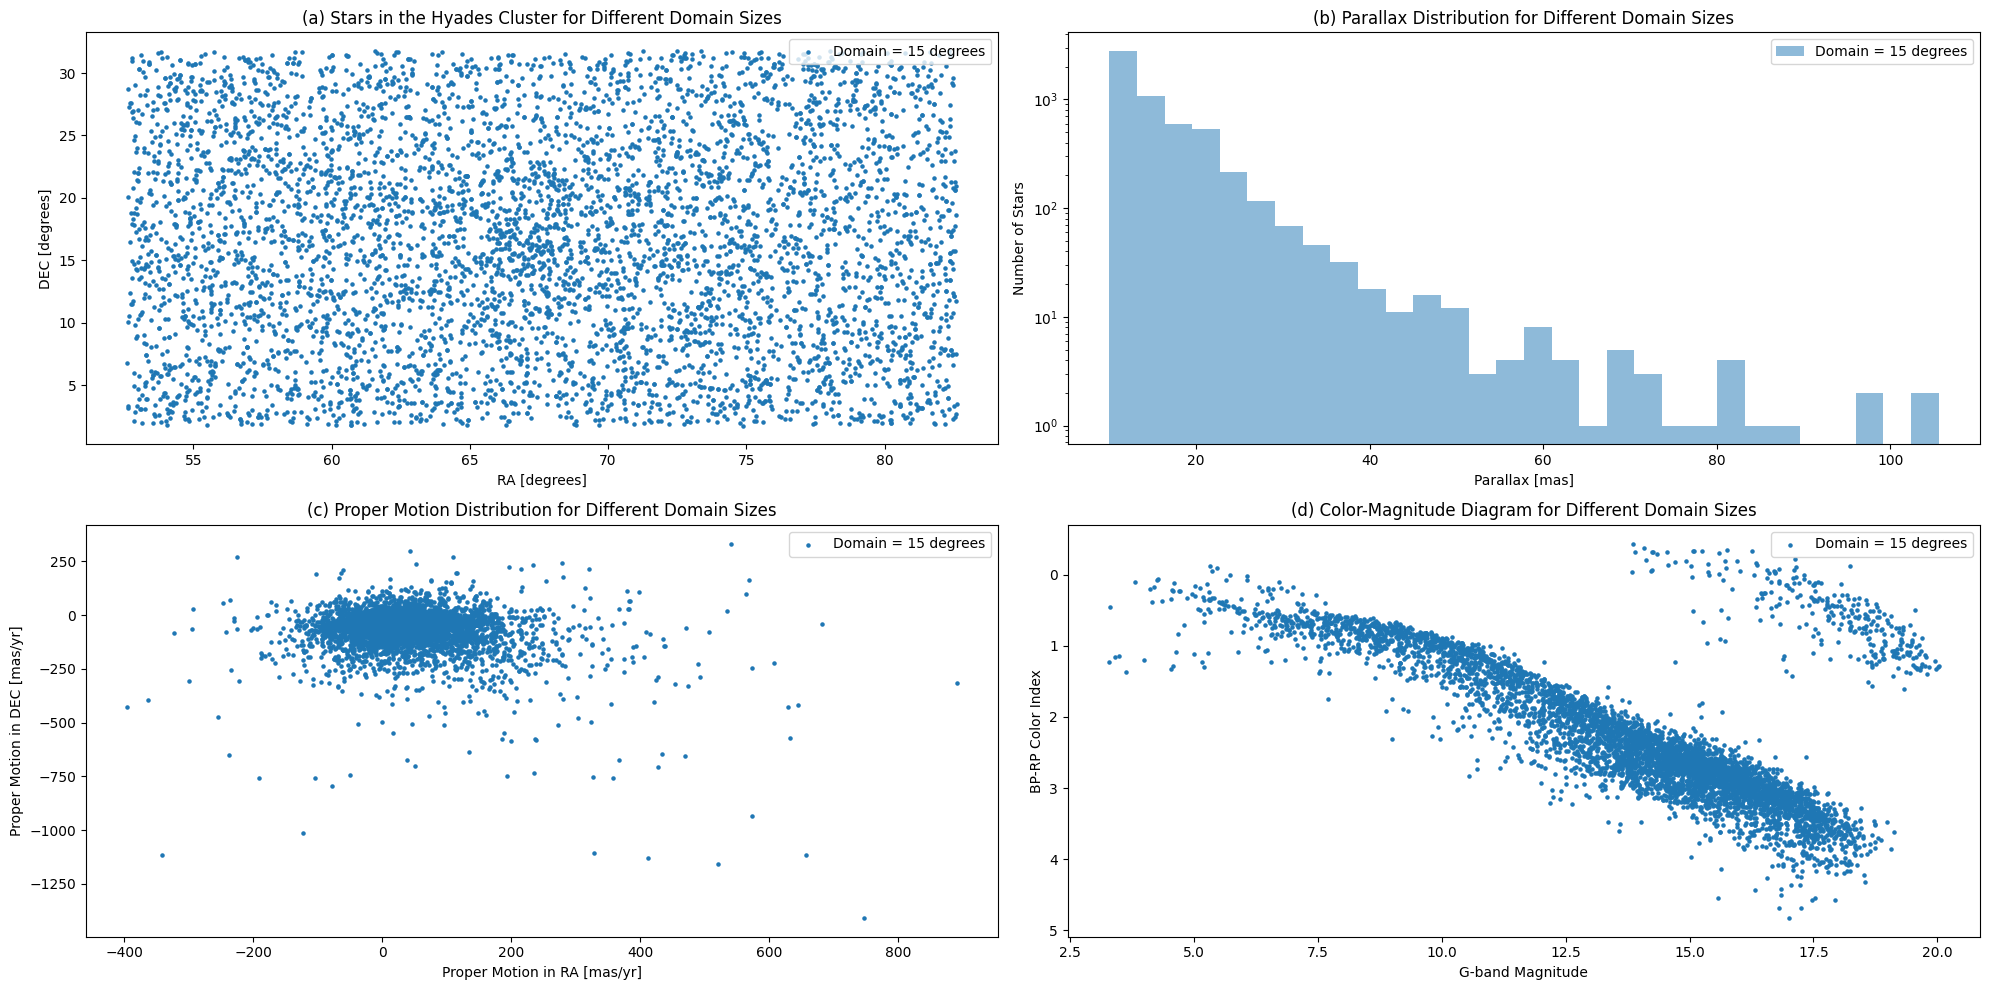

In [31]:


deltas = [1, 5.5/2,5, 10, 15] # Arbitrarily chosen (except 5.5/2, see previous cell)

for i, D in enumerate(deltas):
    fig2,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(20,10))

    mask = (RA_hya-D <= data['ra']) & (data['ra'] <= RA_hya+D ) & (DEC_hya-D <= data['dec']) & (data['dec'] <= DEC_hya+D )
    data_D = data[mask]

    ax1.scatter(data_D['ra'], data_D['dec'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax2.hist(data_D['parallax'], bins=30, alpha=0.5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax3.scatter(data_D['PMRA'], data_D['PMDEC'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax4.scatter(data_D['phot_g_mean_mag'], data_D['bp_rp'], s=5, label=f'Domain = {D} degrees', zorder=-2*i)

    ax1.set_xlabel('RA [degrees]')
    ax1.set_ylabel('DEC [degrees]')
    ax1.set_title('(a) Stars in the Hyades Cluster for Different Domain Sizes')
    ax1.legend(loc='upper right')


    ax2.set_xlabel('Parallax [mas]')
    ax2.set_ylabel('Number of Stars')
    ax2.set_yscale('log')
    ax2.set_title('(b) Parallax Distribution for Different Domain Sizes')
    ax2.legend(loc='upper right')

    ax3.set_xlabel('Proper Motion in RA [mas/yr]')
    ax3.set_ylabel('Proper Motion in DEC [mas/yr]')
    ax3.set_title('(c) Proper Motion Distribution for Different Domain Sizes')
    ax3.legend(loc='upper right')

    ax4.set_xlabel('G-band Magnitude')
    ax4.set_ylabel('BP-RP Color Index')
    ax4.set_title('(d) Color-Magnitude Diagram for Different Domain Sizes')
    ax4.invert_yaxis()  # Invert y-axis for magnitude
    ax4.legend(loc='upper right')

    plt.tight_layout()

plt.show()





# OPDRACHT 3

In [38]:
# We can see that the data from 2.75 degrees is the most sharp (clear cutoffs)
parallax_bounds = (10,30) # [mas]
PMRA_bounds = (-100,350) # [mas/yr]
PMDEC_bounds = (-50,50)
Delta = 2.75

mask_parallax = (parallax_bounds[0]-data['parallax_error'] <= data['parallax']) & (data['parallax'] <= parallax_bounds[1]+data['parallax_error'])
mask_PMRA = (PMRA_bounds[0]-data['PMRA_ERROR'] <= data['PMRA']) & (data['PMRA'] <= PMRA_bounds[1]+data['PMRA_ERROR'])
mask_PMDEC = (PMDEC_bounds[0]-data['PMDEC_ERROR'] <= data['PMDEC']) & (data['PMDEC'] <= PMDEC_bounds[1]+data['PMDEC_ERROR'])
base_mask = (RA_hya-Delta-data['RA_ERROR'] <= data['ra']) & (data['ra'] <= RA_hya+Delta+data['RA_ERROR'] ) & (DEC_hya-Delta-data['DEC_ERROR'] <= data['dec']) & (data['dec'] <= DEC_hya+Delta+data['DEC_ERROR'] )

mask1 = base_mask & mask_PMRA & mask_PMDEC
mask2 = base_mask & mask_parallax
selection1 = data[mask1]
selection2 = data[mask2]
selection_B = data[mask1 & mask_parallax]
print(f"Number of stars in selection 1 (proper motion): {len(selection1)}")
print(f"Number of stars in selection 2 (parallax): {len(selection2)}")
print(f"Number of stars in selection B (proper motion + parallax): {len(selection_B)}")

Number of stars in selection 1 (proper motion): 223
Number of stars in selection 2 (parallax): 318
Number of stars in selection B (proper motion + parallax): 223


# OPDRACHT 4

In [42]:
# we can see that selection1 is inside selection2, so the propere motion is the best guess.


mean_parallax = np.mean(selection_B['parallax'])
print(f"Mean parallax of selection B: {mean_parallax:.2f} mas")

mean_parallax_error = np.mean(selection_B['parallax_error'])
print(f"Mean parallax error of selection B: {mean_parallax_error:.2f} mas")

distance_pc = 1000 / mean_parallax
distance_pc_err = 1000 / mean_parallax**2 * mean_parallax_error
print(f"Distance to the Hyades cluster: {distance_pc:.2f} pc ± {distance_pc_err:.2f} pc")

Mean parallax of selection B: 17.49 mas
Mean parallax error of selection B: 0.11 mas
Distance to the Hyades cluster: 57.17 pc ± 0.37 pc


# OPDRACHT 5

In [ ]:

file_loc = rf"{cwd}\isochronesGaiaDR2_z0.020.dat"
with open (file_loc, 'r') as f:
    Nc = int(f.readline().strip()) # Number of colors

    colour_names = [f.readline().strip() for _ in range(Nc)]

    header = f.readline().strip().split()

data_iso = np.loadtxt(file_loc, skiprows=2+Nc)

iso_meta = {
    'Num_colors': Nc,
    'colours': colour_names,
    'header': header
}
data_iso = {name: data_iso[:, i] for i, name in enumerate(colour_names)}


# plot d opnieuw, maar ook met de isochronen, tbh eerst ff isochronen doen
